# Class 13: Intro to NetworkX, Network Science, and Soccer Event Data

Goal of today's class:
1. Review basic network properties and vocabulary
2. Work with graph objects in `networkx`
3. Introduce soccer event data, using the StatsBomb open-data repository
4. Load event JSON files, inspect their fields, and make a few basic visualizations
5. Build a passing network for one real match and compute some network properties

__________

1. Come in. Sit down. Open your notebook.
2. Find this notebook in your `/Class_13/` folder.
3. Run cells as we go, and stop often to inspect the objects.

__________

### Roadmap

We are really doing two things today.

**Part I** is an introduction to `networkx` and a few basic ideas from network science.  
This part should feel familiar.

**Part II** is an application. We will use **soccer event data** and turn a match into a network:
- players will be **nodes**
- completed passes will be **directed edges**
- repeated passes will be **edge weights**

The point is to see how the same graph ideas carry over once the data are real.

## Basic Definitions
- An ***undirected graph*** $G$ is defined by a pair of sets $G = (V,E)$, where $V$ is a non-empty countable set of elements referred to as *nodes* or *vertices* and $E$ is a set of *non-ordered* pairs of different vertices, known as *edges* or *links*.
- A ***directed graph*** (sometimes shorthanded to "digraph") is defined by a pair of sets $G = (V,E)$, where $V$ is non-empty countable set of elements, *nodes* or *vertices*, and $E$ is a set of *ordered* pairs of different vertices, **directed** *edges* or *links*.

Let us denote the **total number of nodes** in the graph as $N$ (also referred to as the **cardinality** of the set $V$, or sometimes the **order** of the graph) and the **total number of edges** as $M$.

The **density** of the graph is the number of edges of graph $G$ divided by the maximum possible number of edges:
- in an *undirected graph*, density = $\dfrac{2 M}{N(N-1)}$

- in an *directed graph*, density = $\dfrac{M}{N(N-1)}$

## Network Representations

Based on the basic definitions above, all we need to create a network is 1) a list of nodes, and 2) a list of which nodes are connected (i.e., edges). We say that two vertices $i$ and $j$ are adjacent or connected or (nearest) neighbors if there exists an edge $e_{ij} \in E$ joining them. Note that if we assume that there are no nodes with zero connections, all we really need to represent our graph is a list of edges.


For **undirected graphs**, an **edgelist** is a set of *non-ordered node pairs* where each pair represents a link between two nodes.

![](images/graph_undirected.png)
Figure 1: Undirected Graph

For example, in Figure 1 above, the undirected network has the following edgelist:
$\left\{ (0,1),(0,2),(0,3),(0,4),(1,2),(1,3),(1,5),(2,3),(4,5) \right\}$.

![](images/graph_directed.png)
Figure 2: Directed Graph

In the case of a **directed graph**, the edgelist is a set of *ordered node pairs*, where directionality of the connection is encoded in the order that the nodes are listed (i.e., the first node can be thought of as the *source*, and the second node as the *target*). As an example, the directed graph in Figure 2 above can be represented by the following edgelist: $\left\{ (0,1),(0,5),(1,2),(1,3),(2,5),(3,2),(4,0),(4,5) \right\}$.

_______

A graph $G=(V,E)$ can be represented mathematically by an $N\times N$ ***adjancency matrix*** $A$.

$$ A = 
\begin{pmatrix}
    a_{1,1} & a_{1,2} & \cdots & a_{1,N} \\
    a_{2,1} & a_{2,2} & \cdots & a_{2,N} \\
    \vdots  & \vdots  & \ddots & \vdots  \\
    a_{N,1} & a_{N,2} & \cdots & a_{N,N} 
\end{pmatrix},$$
 
where $\forall i,j \in V$, 

$$a_{ij} =
\begin{cases}
    1    & \quad \text{if } e_{ij} \in E\\
    0    & \quad \text{if } e_{ij} \notin E\\
\end{cases}$$
    
In an *undirected graph*, the adjacency matrix $A$ is symmetric such that $a_{ij} = a_{ji}$; in a *directed graph* the elements $a_{ij}$ and $a_{ji}$ are not necessarily equivalent (a property called *reciprocity*).

**Note:** A lot in network science leads back to *linear algebra*, a topic in mathematics that describes matrices and their properties. The fact that we can represent a network as a matrix opens a world of possible questions we can ask of the graphs we'll be working with.

Adjacency matrices also permit us to represent weighted edges, yielding a ***weighted graph***, which is a network (undirected or directed) where we associate a value (usually a real number) to each edge. This weighted graph $G=(V,E,\Omega)$, then, we can define using with a $N\times N$ *weighted adjancency matrix*, $W$.

$$ W = 
\begin{pmatrix}
    w_{1,1} & w_{1,2} & \cdots & w_{1,N} \\
    w_{2,1} & w_{2,2} & \cdots & w_{2,N} \\
    \vdots  & \vdots  & \ddots & \vdots  \\
    w_{N,1} & w_{N,2} & \cdots & w_{N,N} 
\end{pmatrix},
$$
 
where $\forall i,j \in V$,

$$w_{ij} =
\begin{cases}
    w    & \quad \text{if } e_{ij} \in E\\
    0    & \quad \text{if } e_{ij} \notin E\\
\end{cases}
$$
______________

### Adjacency Matrices and Network Properties

Consider the undirected adjacency matrix, $A$, of the graph in Figure 1, above:

$$ A = 
\begin{pmatrix}
    0 & 1 & 1 & 1 & 1 & 0 \\
    1 & 0 & 1 & 1 & 0 & 1 \\
    1 & 1 & 0 & 1 & 0 & 0 \\
    1 & 1 & 1 & 0 & 0 & 0 \\
    1 & 0 & 0 & 0 & 0 & 1 \\
    0 & 1 & 0 & 0 & 1 & 0 \\
\end{pmatrix}.$$

Often, working with an adjacency matrix is not ideal. Matrices are large objects, and the price we pay to loop over one node's neighbors is high (i.e. $O(N)$), and it can be quite impractical when dealing with large but **sparse** graphs (networks for which the number of edges $|E|$ in the graph scales as $|E| \sim N^\alpha$ with $\alpha <2$).

For this reason, we can also consider storing a network using an **adjacency list** rather than an adjacency matrix. This lets us store a graph as a set of lists where each list is associated with each node and its list of neighbors. The table below shows the adjacency list for the graph in Figure 1.

| Vertex | Neighbors   |
|------|------|
|   0  | [1,2,3,4] |
|   1  | [0,2,3,5] |
|   2  | [0,1,3] |
|   3  | [0,1,2] |
|   4  | [0,5] |
|   5  | [1,4] |


#### Sanity check (and little `networkx` preview)

In [1]:
import networkx as nx
import numpy as np

edgelist = [(0,1),(0,2),(0,3),(0,4),(1,2),(1,3),(1,5),(2,3),(4,5)]

adjacency_dict = {0: [1,2,3,4],
                  1: [0,2,3,5],
                  2: [0,1,3],
                  3: [0,1,2],
                  4: [0,5],
                  5: [1,4]}

adjacency_matrix = np.array([[0,1,1,1,1,0],
                             [1,0,1,1,0,1],
                             [1,1,0,1,0,0],
                             [1,1,1,0,0,0],
                             [1,0,0,0,0,1],
                             [0,1,0,0,1,0]])


G1 = nx.from_edgelist(edgelist, create_using=nx.Graph)
G2 = nx.from_dict_of_lists(adjacency_dict, create_using=nx.Graph)
G3 = nx.from_numpy_array(adjacency_matrix, create_using=nx.Graph)

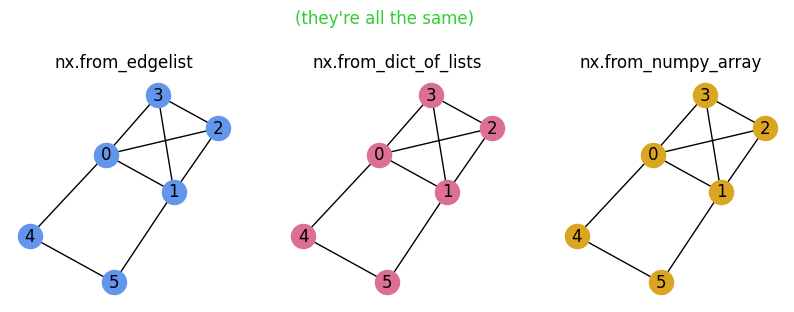

In [2]:
import matplotlib.pyplot as plt

pos = nx.spring_layout(G1)

fig, ax = plt.subplots(1,3,figsize=(10,3),dpi=100)

nx.draw(G1, pos=pos, node_color='cornflowerblue', with_labels=True, ax=ax[0])
ax[0].set_title('nx.from_edgelist')

nx.draw(G2, pos=pos, node_color='palevioletred', with_labels=True, ax=ax[1])
ax[1].set_title('nx.from_dict_of_lists')

nx.draw(G3, pos=pos, node_color='goldenrod', with_labels=True, ax=ax[2])
ax[2].set_title('nx.from_numpy_array')


plt.suptitle("(they're all the same)",y=1.1,color='limegreen')


plt.show()

Nice!
___________

## Diving into `networkx`

In [3]:
import networkx as nx
nx.__version__

'3.1'

### Graph objects
From the `networkx` documentation page: 

    "By definition, a Graph is a collection of nodes (vertices) along with identified pairs of nodes (called edges, links, etc). In NetworkX, nodes can be any hashable object e.g., a text string, an image, an XML object, another Graph, a customized node object, etc."
    
Source: https://networkx.org/documentation/latest/tutorial.html

___________

#### Note on Bipartite Networks

A ***bipartite*** graph (or "two-mode network") is a graph with two distinct sets or classes of vertices, such that edges only exist *between* the two vertex types. Formally, a graph $G=(V,E)$ is bipartite if the set of nodes $V$ is composed by two distinct and disjoint sets $V_1, V_2$ and all edges $e_{i,j} \in E$ are such that $i\in V_1$ and $j\in V_2$.

A bipartite graph $G=(V = \{V_1,V_2\},E)$ can be represented mathematically by a $N_1\times N_2$ ***incidence matrix***, $B$

$$ B = 
\begin{pmatrix}
    b_{1,1} & b_{1,2} & \cdots & b_{1,N_2} \\
    \vdots  & \vdots  & \ddots & \vdots  \\
    b_{N_1,1} & b_{N,2} & \cdots & b_{N_1,N_2} 
\end{pmatrix},$$

where $N_1 = |V_1|$, $N_2 = |V_2|$, and $\forall i \in V_1$ and $j \in V_2$, 

$$b_{i,j} =
\begin{cases}
    1    & \quad \text{if } e_{i,j} \in E\\
    0    & \quad \text{if } e_{i,j} \notin E\\
\end{cases}$$

<!-- In this example we are going to use a bipartite graph obtained collecting users <i>metadata</i>. <br>
The analysis in this example is based on information gathered by our field agent Mr David Hackett Fischer and published in an Appendix to his report to the government. For more details consult: https://github.com/kjhealy/revere .
 -->
_________________

#### Note on Multigraphs

The most common objects we'll be using in `networkx` are `nx.Graph` and `nx.DiGraph`, but there are other classes of graphs that may be more suitable for describing certain processes. `networkx`'s `nx.MultiGraph` and `nx.MultiDiGraph` permit multiple edges (directed or not) to exist between pairs of nodes.

For instance, consider a bipartite network projection where pairs of students share a connection if they are enrolled in the same class at the same time (e.g. this current class). What if two students are in more than one class together? What are different ways to imagine incorporating this into the graph structure? When might it matter?

**Important to note**: Some algorithms are not well-defined (or, are least, not clearly-defined) on multigraphs, for example there are multiple ways to imagine shortest paths, betweenness, clustering, etc. when there are multiple links connecting pairs of nodes.
_____________

**First up:** Let's create two distinct empty graphs:

In [6]:
graph = nx.Graph() # undirected graph
digraph = nx.DiGraph() # directed graph

#### Adding nodes:

In [7]:
# We can populate the graphs with some nodes, and we can do this in several ways:

# 1) We can add one node at the time
for i in range(10):
    graph.add_node(i)

In [11]:
list(graph.nodes())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [12]:
# 2) We can add nodes from a list or any other iterable container
nodes = ['a','b','c','d','e'] # notice that nodes can be strings
digraph.add_nodes_from(nodes)

In [13]:
list(digraph.nodes())

['a', 'b', 'c', 'd', 'e']

In [14]:
# 3) We can also directly add edges and if the node is not present, it will be added
graph.add_edge(1,20)

In [15]:
list(graph.nodes())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 20]

In [16]:
graph.add_edge('alice','bob')
list(graph.nodes())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 20, 'alice', 'bob']

#### Adding edges:

In [17]:
# Now that we added a bunch of nodes, we can add some edges
# 1) We can add one edge at the time (as we have just witnessed above)
digraph.add_edge('a','b')
digraph.add_edge('c','a')

In [18]:
list(digraph.edges())

[('a', 'b'), ('c', 'a')]

In [19]:
# 2) We can add an entire edge list all at once
edge_list = [(1,2), (3,5), (9,4), (4,7)]
graph.add_edges_from(edge_list)

In [20]:
# We can retrieve the list of edges in each graph by simply running
print(graph.edges())

[(1, 20), (1, 2), (3, 5), (4, 9), (4, 7), ('alice', 'bob')]


In [16]:
# When graphs are big (either in terms of the number of nodes or in terms of the number of edges),
# it is more convenient to loop over "iterators" and not over lists.
for edge in graph.edges():
    print(edge)

(1, 20)
(1, 2)
(3, 5)
(4, 9)
(4, 7)
('alice', 'bob')


In [21]:
# We can also retrieve the list of neighbors of a given node
print(list(graph.neighbors(1)))
print(list(digraph.predecessors('a')))
print(list(digraph.successors('a')))

[20, 2]
['c']
['b']


#### Adding node and edge attributes
In `networkx`, we can add additional features to our graphs above and beyond simply nodes and edges. In particular, we can add *attributes*.

In [25]:
# For example, we might wanna add a "size" attribute to each node, 
# so we can use it once we decide to visualize a graph.
graph.add_node(50, size=100, weight=90, height=600)

In [26]:
list(graph.nodes())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 20, 'alice', 'bob', 50]

In [27]:
print(graph.nodes(data=True)) # the "data=True" bit means you want to see node attributes

[(0, {}), (1, {}), (2, {}), (3, {}), (4, {}), (5, {}), (6, {}), (7, {}), (8, {}), (9, {}), (20, {}), ('alice', {}), ('bob', {}), (50, {'size': 100, 'weight': 90, 'height_brennan': 600, 'height': 600})]


In [29]:
# or we might want to associate a "weight" to each edge we include in the graph
digraph.add_edge('a','b',weight=10, timestamp='monday')

In [30]:
print(digraph.edges(data=True))

[('a', 'b', {'weight': 10, 'timestamp': 'monday'}), ('c', 'a', {})]


In [33]:
# However, we might also want to add a new attribute to all nodes or edges already present in the graph.
# This can be done using the "set_node_attributes" or "set_edge_attributes" methods provided by networkx:

new_node_attribute_values = {node:75 for node in graph.nodes()}
nx.set_node_attributes(graph, new_node_attribute_values, 'size')

# graph= the data you want, new_node_attribute_values is the variable you're adding,
# 'size'= is the name of the attribute

In [34]:
print(graph.nodes(data=True))

[(0, {'size': 75}), (1, {'size': 75}), (2, {'size': 75}), (3, {'size': 75}), (4, {'size': 75}), (5, {'size': 75}), (6, {'size': 75}), (7, {'size': 75}), (8, {'size': 75}), (9, {'size': 75}), (20, {'size': 75}), ('alice', {'size': 75}), ('bob', {'size': 75}), (50, {'size': 75, 'weight': 90, 'height_brennan': 600, 'height': 600})]


In [35]:
new_edge_attribute_values = {edge:'blue' for edge in graph.edges()}
nx.set_edge_attributes(graph, new_edge_attribute_values, 'color')

In [36]:
nx.get_edge_attributes(graph,'color')

{(1, 20): 'blue',
 (1, 2): 'blue',
 (3, 5): 'blue',
 (4, 9): 'blue',
 (4, 7): 'blue',
 ('alice', 'bob'): 'blue'}

In [37]:
print(graph.edges(data=True))

[(1, 20, {'color': 'blue'}), (1, 2, {'color': 'blue'}), (3, 5, {'color': 'blue'}), (4, 9, {'color': 'blue'}), (4, 7, {'color': 'blue'}), ('alice', 'bob', {'color': 'blue'})]


#### Removing Nodes and Edges

In [38]:
# We can remove all nodes and edges
digraph.clear()
print(digraph.nodes())

[]


In [39]:
# Or simply remove some of the nodes/edges one item at the time
graph.remove_edge(1,2)
graph.remove_node(7)

In [40]:
# ...or several items all at once
edge_list = [(1,2), (9,4)]
graph.remove_edges_from(edge_list)

node_list = [3,5]
graph.remove_nodes_from(node_list)

________
### Basic operations and descriptions of the network
#### Get the number of nodes and links in the graph

In [46]:
edge_list = [(1,2), (3,5), (9,4), (4,7)]
graph.add_edges_from(edge_list)

print("Number of nodes: %d" % graph.number_of_nodes())
print("Number of edges: %d" % graph.number_of_edges())

Number of nodes: 14
Number of edges: 6


In [47]:
print("Number of nodes ('len'): %d" % len(graph))
print("Number of nodes ('order'): %d" % graph.order())
print("Number of edges ('size'): %d" % graph.size())

Number of nodes ('len'): 14
Number of nodes ('order'): 14
Number of edges ('size'): 6


In [48]:
graph.name = 'My graph'
graph.name

'My graph'

#### Connectivity & Components & Subgraphs

A graph is said to be ***connected*** if there exists a path connecting any two vertices in the graph. An undirected & connected graph without closed loops is known as a **tree**.

A graph $G'= (V',E')$ is said to be a ***subgraph*** of graph $G= (V,E)$ if $N' \subseteq N$ and $E' \subseteq E$. A graph $G'= (V',E')$ ***vertex-induced subgraph*** (or, more colloqially, an  ***induced subgraph***) is a graph that includes only a subset of $V' \subseteq V$ of vertices of graph $G= (V,E)$ and any edge $e_{ij}$ whose vertices $i$ and $j$ are both in $V'$.

nx.is_connected(G): False 



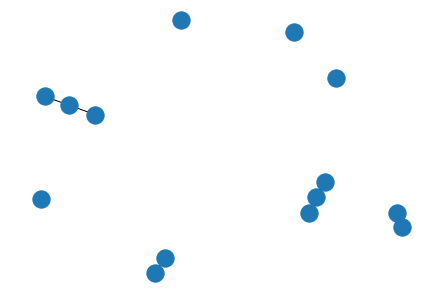

In [50]:
nx.draw(graph);

print("nx.is_connected(G):",nx.is_connected(graph),'\n')

nx.is_connected(G): True 



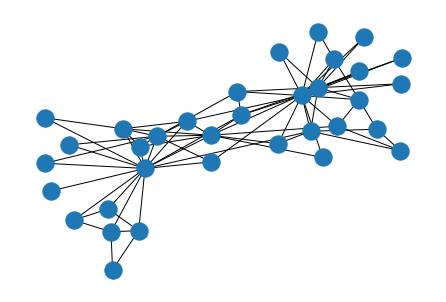

In [51]:
G = nx.karate_club_graph()
nx.draw(G);

print("nx.is_connected(G):",nx.is_connected(G),'\n')

__________
#### Components

A ***component*** $C$ of a graph $G=(V,E)$ is a connected subgraph of $G$. The ***largest connected component*** is simply the connected component with the most nodes in the network. The ***giant component*** of a graph is defined as the component whose size scales with the number of vertices of the graph (i.e. it diverges in the limit $N\rightarrow\infty$).

In a *directed graph*, a we have to introduce the notions of *strong* and *weak* when defining connected components. A ***weakly connected component*** is a connected subgraph where we consider all paths disregarding the direction of the edges and considering the graph *as if* it were undirected. ***Strongly connected components*** are connected subgraphs where edge direction plays an important factor.


##### "Bowtie" Structures of Directed Graphs

If we define two more subgraph structures...
- ***tendrils*** formed by nodes for which it does not exist a directed path that allows them to reach the GSCC, or to be reached from the GSCC;
- ***tubes*** formed by nodes that belong to a directed path connecting GIN to GOUT without crossing the GSCC.

...we complete what's known as the "bowtie" structure of directed graphs.

![](images/bowtie.png)

nx.is_weakly_connected(G_directed): True
nx.is_strongly_connected(G_directed): True


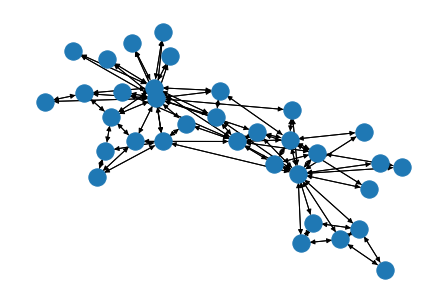

In [52]:
G_directed = nx.to_directed(G)

nx.draw(G_directed);

print("nx.is_weakly_connected(G_directed):",nx.is_weakly_connected(G_directed))
print("nx.is_strongly_connected(G_directed):",nx.is_strongly_connected(G_directed))

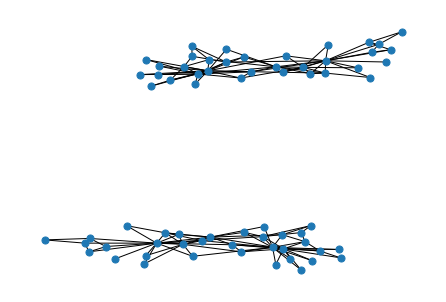

In [57]:
G_union = nx.union(G, G, rename=list(range(2*len(G))))
nx.draw(G_union, node_size=50)

In [58]:
# connected components
nx.connected_components(G)

<generator object connected_components at 0x7fb16998f970>

In [59]:
print(list(nx.connected_components(G)))
print(len(list(nx.connected_components(G))))

[{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}]
1


In [60]:
G_union.remove_node('00')

In [61]:
print(len(list(nx.connected_components(G_union))))

4


In [62]:
largest_cc = max(nx.connected_components(G_union), key=len)
largest_cc

{'10',
 '11',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '12',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '13',
 '130',
 '131',
 '132',
 '133',
 '14',
 '15',
 '16',
 '17',
 '18',
 '19'}

In [63]:
# To create the induced subgraph of each component use:
S = [G_union.subgraph(c).copy() for c in nx.connected_components(G_union)]

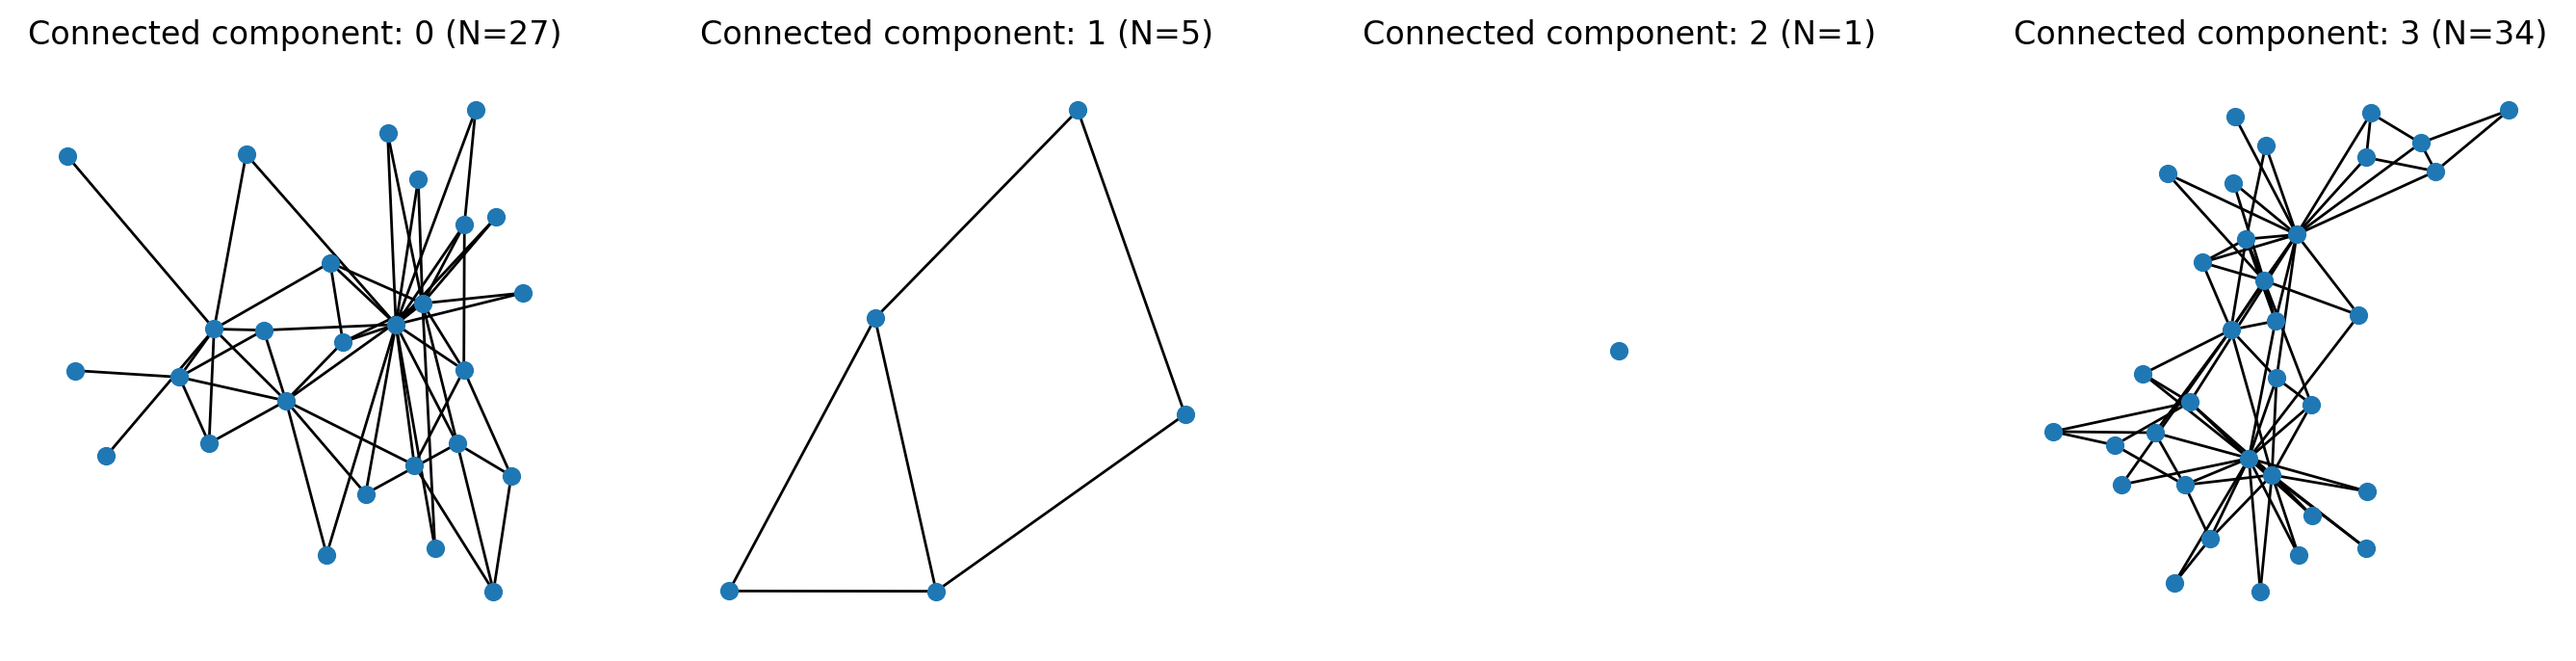

In [64]:
fig, ax = plt.subplots(1,len(S),figsize=(17,4),dpi=200)

for i,s in enumerate(S):
    nx.draw(s, ax=ax[i], node_size=35)
    ax[i].set_title('Connected component: %i (N=%i)'%(i,s.number_of_nodes()))
    
plt.show()

See https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.components.connected_components.html for more information about graphs and subgraphs.

______________

### Network Properties
#### Neighbors and Degrees

The __degree__ $k$ of a vertex is the number of neighbors of that node (i.e., its number of edges).

In an _undirected graph_, the degree of a node $i$ can be easily computed from the adjancency matrix $A$ by counting the number of 1's either over columns or over rows: $k_i = \sum_{j}a_{i,j} = \sum_{j}a_{j,i}$.

In _directed graphs_, we can compute the number of edges pointing towards a given node $i$, 
the __in-degree__ of node $i$, as: $k_i^{in} = \sum_{j}a_{j,i}$; <br>

or the number of edges pointing outwards a given node $j$, 
the __out-degree__ of node $i$, as: $k_i^{out} = \sum_{j}a_{i,j}$.<br>

Then, the __total degree__ of node $i$ in a _directed_ graph can be computed as: $k_i = k_i^{in} + k_i^{out}$.

In `networkx`, degree is a view of single node or of `nbunch` of nodes. If nbunch is omitted, then return degrees of *all* nodes:

In [65]:
nx.degree?

Signature: nx.degree(G, nbunch=None, weight=None)
Docstring:
Returns a degree view of single node or of nbunch of nodes.
If nbunch is omitted, then return degrees of *all* nodes.
File:      /usr/local/anaconda3/envs/covid/lib/python3.8/site-packages/networkx/classes/function.py
Type:      function


In [68]:
G = nx.karate_club_graph()
G.degree()

DegreeView({0: 16, 1: 9, 2: 10, 3: 6, 4: 3, 5: 4, 6: 4, 7: 4, 8: 5, 9: 2, 10: 3, 11: 1, 12: 2, 13: 5, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 3, 20: 2, 21: 2, 22: 2, 23: 5, 24: 3, 25: 3, 26: 2, 27: 4, 28: 3, 29: 4, 30: 4, 31: 6, 32: 12, 33: 17})

In [69]:
node_i = 0
print("Degree of node %i is %i"%(node_i,G.degree(node_i)))

Degree of node 0 is 16


In [70]:
list(dict(G.degree()).keys())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33]

In [71]:
dict(G.degree())

{0: 16,
 1: 9,
 2: 10,
 3: 6,
 4: 3,
 5: 4,
 6: 4,
 7: 4,
 8: 5,
 9: 2,
 10: 3,
 11: 1,
 12: 2,
 13: 5,
 14: 2,
 15: 2,
 16: 2,
 17: 2,
 18: 2,
 19: 3,
 20: 2,
 21: 2,
 22: 2,
 23: 5,
 24: 3,
 25: 3,
 26: 2,
 27: 4,
 28: 3,
 29: 4,
 30: 4,
 31: 6,
 32: 12,
 33: 17}

In [72]:
degree_vals = list(dict(G.degree).values())

Wait a second though... isn't the Karate Club a weighted graph? 

The ___strength___ $s$ of a node isthe sum of the weights of edges connecting a given node and its neighbors. For an *undirected* weighted graph, the strength of node $i$ can be computed from the weighted adjancency matrix $W$ by summing the values of the weights either over the columns or over rows: $s_i = \sum_{j}w_{ij} = \sum_{j}w_{ji}$.

In [73]:
G.degree(weight='weight')

DegreeView({0: 42, 1: 29, 2: 33, 3: 18, 4: 8, 5: 14, 6: 13, 7: 13, 8: 17, 9: 3, 10: 8, 11: 3, 12: 4, 13: 17, 14: 5, 15: 7, 16: 6, 17: 3, 18: 3, 19: 5, 20: 4, 21: 4, 22: 5, 23: 21, 24: 7, 25: 14, 26: 6, 27: 13, 28: 6, 29: 13, 30: 11, 31: 21, 32: 38, 33: 48})

In *directed* weighted graphs, we compute the sum of the weights of the in/out edges of node $i$; the ***in-strength*** of node $i$ is $s_i^{in} = \sum_{j}w_{ji}$, and the ***out-strength*** of node $i$ is: $s_i^{out} = \sum_{j}w_{ij}$.

Therefore, the ***total strength*** of node $i$ in a *directed* graph can be computed as: $s_i = s_i^{in} + s_i^{out}$.

________________

In [102]:
G_er = nx.erdos_renyi_graph(10,0.2)

## Generating Random Graphs

### Static Random Graph Models
#### Erdős-Rényi Model(s)

The original formulation: a $G_{(N,M)}$ graph is constructed starting from a set $V$ of $N$ different vertices connected at random by $M$ edges (Erdős and Rényi, 1959; 1960; 1961).

A variation of this model proposed by Gilbert (1959) constructs a $G_{(N,p)}$ graph from a set $V$ of $N$ different vertices in which each of the possibile $\frac{N(N-1)}{2}$ edges is present with probability $p$ (the _connection probability_).

The two models are statistically equivalent as $N \rightarrow \infty$ with:

$$ \dfrac{pN(N-1)}{2} = E $$

<!-- The exact ___degree distribution___ $P(k)$ of an Erdos-Renyi graph is a __Binomial distribution__:

$$ P(k) = \binom{N-1}{k} p^k (1-p)^{N-1-k},$$

in the limit for $N>> \langle k \rangle$ the ___degree distribution___ $P(k)$ can be approximated by the __Poisson distribution__:
$$ P(k) = e^{-\langle k \rangle}\frac{\langle k \rangle^k}{k!} $$ -->

In [105]:
N = 100
p = 0.01
E = p*N*(N-1)*0.5
av_deg = (N-1)*p
er = nx.erdos_renyi_graph(N,p) 
# the function called erdos_renyi actually generates the Gilbert variation of the model

## To generate the original Erdős-Rényi graph use
# er = nx.gnm_random_graph(N,int(E))

## And to generate the Gilbert graph you can also use
# g = nx.gnp_random_graph(N,p)

The average number of edges in this graph is:

$$ \langle E \rangle = \dfrac{N(N-1)p}{2}, $$

and the average degree is:

$$ \langle k \rangle = \frac{2\langle E \rangle}{N} = (N-1)p \simeq Np .$$

In [106]:
# the average number of edges generated in the construction of the graph
exp_E = 0.5*N*(N-1)*p 

B = 2000 # number of replications
actual_E = [nx.gnp_random_graph(N,p).number_of_edges() for b in range(B)]

print("Expected mean number of edges: %1.2f" % exp_E)
print("Actual mean number of edges: %1.2f (%d replications)" % (np.mean(actual_E),B))

Expected mean number of edges: 49.50
Actual mean number of edges: 49.45 (2000 replications)


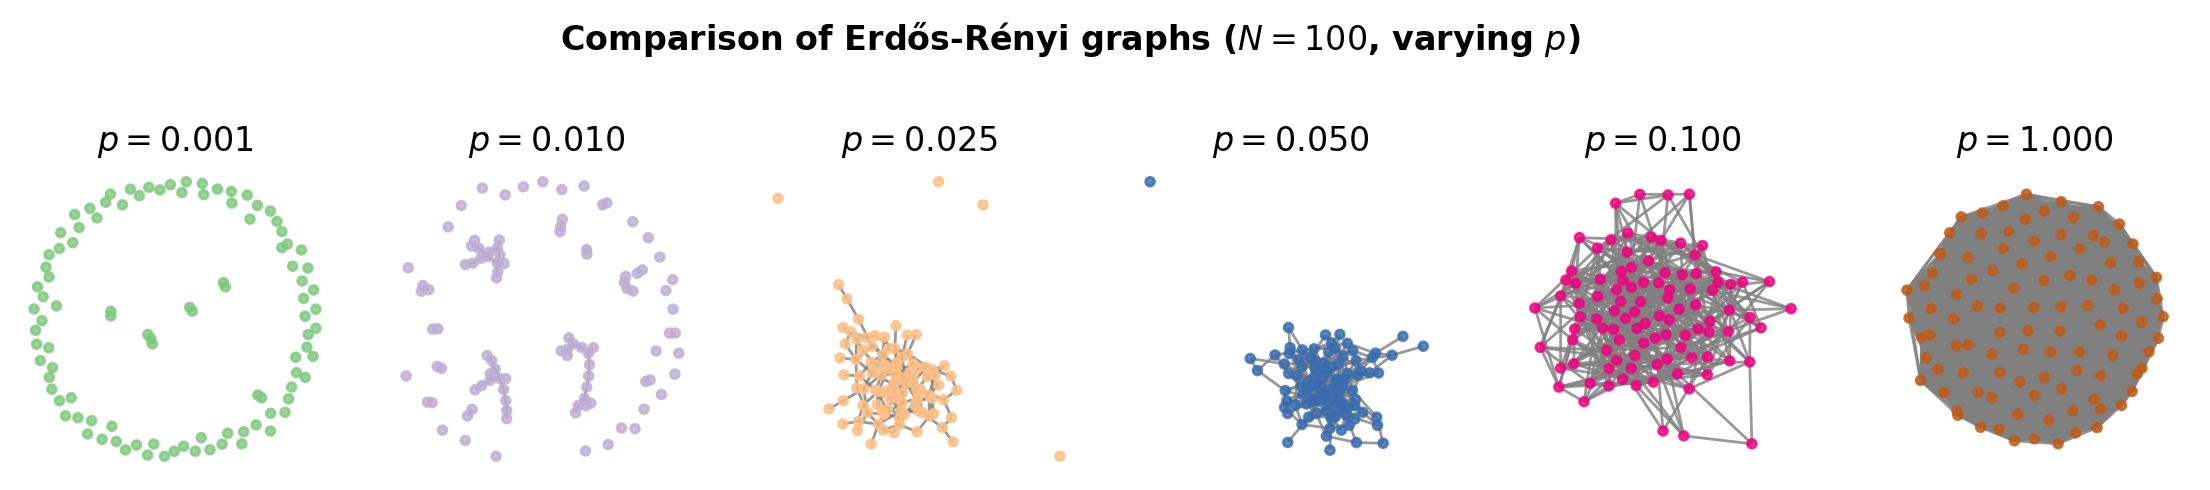

In [107]:
fig, ax = plt.subplots(1,6,figsize=(14,2),dpi=200)

N = 100
for i,p in enumerate([0.001, 0.01, 0.025, 0.05, 0.1, 1.0]):
    G = nx.erdos_renyi_graph(N,p)
    nx.draw_spring(G, ax=ax[i], node_size=10, node_color=[i/6]*N,
                   vmin=0, vmax=1, cmap='Accent', edge_color='.5', alpha=0.8)
    ax[i].set_title(r'$p=%.3f$'%p)


plt.suptitle(r'Comparison of Erdős-Rényi graphs ($N=%i$, varying $p$)'%N,
             y=1.25, fontweight='bold')
    
plt.show()

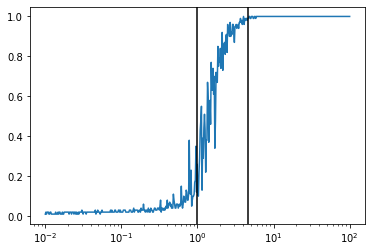

In [129]:
ps = np.logspace(-4,0,500)
N = 100

out = {}
for p in ps:
    G_i = nx.erdos_renyi_graph(N,p)
    Gcc = sorted(nx.connected_components(G_i), key=len, reverse=True)
    G0 = G.subgraph(Gcc[0])
    out[p*N] = G0.number_of_nodes()/N
    
    
plt.semilogx(list(out.keys()),
             list(out.values()))
plt.axvline(1, color='k')
plt.axvline(np.log(N), color='k')

____
#### Random geometric graphs

Erdős-Rényi graphs are quite powerful, useful objects, despite their lack of realism. The model requires few (two) parameters, which can often allow them to be easily studied analytically numerically. Another similar family of random graphs is known as ***random geometric graphs***. Constructing a random geometric graph (RGG) involves randomly assigning $N$ nodes to positions on a geometric surface, then connecting each pair of nodes according to some function of their distance $d(i,j)$.

A simple version of this is to place $N$ nodes uniformly at random in the unit square, and connect every pair of nodes if the distance between the nodes is at most radius $r$.

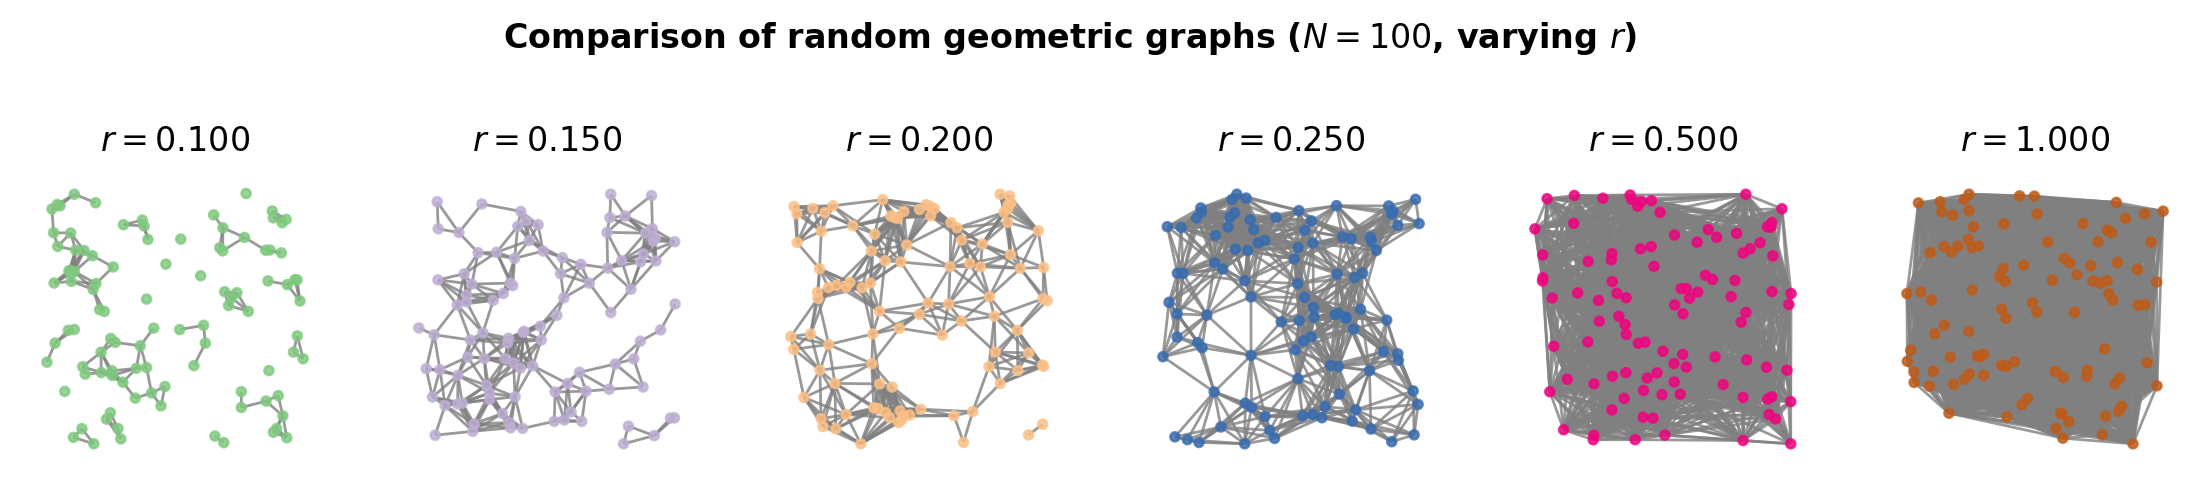

In [128]:
fig, ax = plt.subplots(1,6,figsize=(14,2),dpi=200)

N = 100
for i,r in enumerate([0.1, 0.15, 0.2, 0.25, 0.5, 1.0]):
    G = nx.random_geometric_graph(N,r)
    pos = nx.get_node_attributes(G,'pos')
    nx.draw(G, pos=pos, ax=ax[i], node_size=10, node_color=[i/6]*N,
            vmin=0, vmax=1, cmap='Accent', edge_color='.5', alpha=0.8)
    ax[i].set_title(r'$r=%.3f$'%r)


plt.suptitle(r'Comparison of random geometric graphs ($N=%i$, varying $r$)'%N,
             y=1.25, fontweight='bold')
    
plt.show()

In [130]:
rs = np.logspace(-4,0,500)
N = 100

out_r = {}
out_p = {}
for r in rs:
    G_i = nx.random_geometric_graph(N,r)
    Gcc = sorted(nx.connected_components(G_i), key=len, reverse=True)
    G0 = G.subgraph(Gcc[0])
    p = nx.density(G_i)
    out_p[p*N] = G0.number_of_nodes()/N
    out_r[p*N] = p

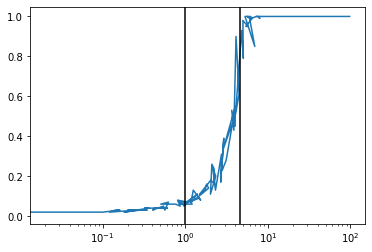

In [132]:

plt.semilogx(list(out_p.keys()),
             list(out_p.values()))
plt.axvline(1, color='k')
plt.axvline(np.log(N), color='k')

### Preview of where we are headed

In a soccer passing network, players are nodes and pass counts become **edge weights**.

That means:
- **degree** asks: *how many teammates do I connect to?*
- **in-degree / out-degree** ask: *how many distinct teammates pass to me / receive from me?*
- **strength** asks: *how much total passing volume flows through me?*

So the weighted, directed language from above is exactly the language we need for event data.

__________

## Part II: From event logs to passing networks

Up to now, most of our graphs have been either toy examples or classic network datasets.

Now we will do the same workflow on a real match:
1. load a match from the **StatsBomb open-data** repository,
2. inspect the event JSON structure,
3. make a few simple exploratory visualizations,
4. and then aggregate passes into a **directed weighted network**.

Same ideas as before. Different data source.

### What is soccer event data?

A soccer **event dataset** is a time-ordered log of actions during a match.  
Each record corresponds to one event.

Typical events include:
- passes
- shots
- carries/dribbles
- pressures
- fouls
- recoveries
- substitutions
- goalkeeper actions

So each event usually has:
- a timestamp,
- a team and player,
- an event type,
- and often a pitch location.

This is different from **tracking data**, which records player and ball positions continuously over time.  
Event data is much sparser, but it is also much easier to obtain, inspect, and work with.

For passing networks, shot maps, possession summaries, and many other first analyses, event data is already enough.

StatsBomb also provide **360 data** for selected matches, but today we will stay with the event logs and lineup files.

### A little context from the literature

Passing networks are already a standard example in sports analytics.

A few useful landmarks:

1. **López Peña and Touchette (2012)** treat players as nodes and passes as directed weighted links, and show how network measures can be used to describe strategy and player importance.
2. **Buldú et al. (2018)** emphasize that football passing networks should not only be thought of as static graphs, but also in terms of space, time, and multilayer structure.
3. **Caicedo-Parada et al. (2020)** review passing networks and tactical action in football and summarize a number of common approaches.
4. **Alves et al. (2025)** provide a more recent systematic review of social network analysis in football.

We are not trying to reproduce that literature here.  
We just want enough context to know that this is already a well-established idea, and then we will build one ourselves.

### The StatsBomb open-data repository

StatsBomb make a public football dataset available on GitHub.

The repository is organized in a pretty simple way:

- `competitions.json` gives competition/season metadata
- `matches/<competition_id>/<season_id>.json` lists matches for one competition-season
- `events/<match_id>.json` stores the event log for one match
- `lineups/<match_id>.json` stores the lineups for one match
- `three-sixty/<match_id>.json` stores 360 freeze-frame data for selected matches

So the workflow is naturally hierarchical:

**competition → season → match → events/lineups**

That is exactly how we will navigate it here.

If you use the data in a project or paper, attribute StatsBomb as the data source.

In [133]:
import json
from pathlib import Path
from urllib.request import urlopen
from pprint import pprint

import pandas as pd

# Raw files live here on GitHub
SB_BASE_URL = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"

# We keep a local cache so repeated notebook runs are fast
SB_CACHE = Path("data/statsbomb_open_data")
SB_CACHE.mkdir(parents=True, exist_ok=True)

def load_statsbomb_json(relative_path, cache_dir=SB_CACHE, base_url=SB_BASE_URL):
    """Load one JSON file from the StatsBomb open-data repository.

    We first look for a cached local copy. If it is not there, we download the
    file from GitHub, save it locally, and then read it in.
    """
    local_path = cache_dir / relative_path
    local_path.parent.mkdir(parents=True, exist_ok=True)

    if local_path.exists():
        with open(local_path, "r", encoding="utf-8") as f:
            return json.load(f)

    url = f"{base_url}/{relative_path}"
    with urlopen(url) as response:
        text = response.read().decode("utf-8")

    local_path.write_text(text, encoding="utf-8")
    return json.loads(text)


In [139]:
# Load the top-level competition/season table
competitions = load_statsbomb_json("competitions.json")
competitions_df = pd.DataFrame(competitions)

print("Number of competition-season entries:", len(competitions_df))
print("Columns:")
print(list(competitions_df.columns))

competitions_df.head()


Number of competition-season entries: 75
Columns:
['competition_id', 'season_id', 'country_name', 'competition_name', 'competition_gender', 'competition_youth', 'competition_international', 'season_name', 'match_updated', 'match_updated_360', 'match_available_360', 'match_available']


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [140]:
pd.set_option('display.max_columns', 80)


In [141]:
# pd.read_json('data/statsbomb_open_data/events/3869685.json')

In [142]:
# Just to get oriented, look at the World Cup entries in the table
world_cups = (
    competitions_df.loc[
        competitions_df["competition_name"].str.contains("World Cup", case=False, na=False),
        ["competition_id", "season_id", "competition_name", "season_name", "competition_gender"]
    ]
    .drop_duplicates()
    .sort_values(["competition_name", "season_name"])
)

world_cups


,competition_id,season_id,competition_name,season_name,competition_gender
28,1470,274,FIFA U20 World Cup,1979,male
36,43,269,FIFA World Cup,1958,male
35,43,270,FIFA World Cup,1962,male
34,43,272,FIFA World Cup,1970,male
33,43,51,FIFA World Cup,1974,male
32,43,54,FIFA World Cup,1986,male
31,43,55,FIFA World Cup,1990,male
30,43,3,FIFA World Cup,2018,male
29,43,106,FIFA World Cup,2022,male
74,72,30,Women's World Cup,2019,female


For a concrete example, let's use the **2022 men's FIFA World Cup final**.

We will load the competition-season file first, then find the specific match row for **Argentina vs France**.

In [143]:
competition_id = 43   # FIFA World Cup
season_id = 106       # 2022

# Load the match list for that competition-season
matches = load_statsbomb_json(f"matches/{competition_id}/{season_id}.json")

# Keep just a few columns we will actually use
matches_df = pd.DataFrame({
    "match_id": [m["match_id"] for m in matches],
    "match_date": [m["match_date"] for m in matches],
    "home_team": [m["home_team"]["home_team_name"] for m in matches],
    "away_team": [m["away_team"]["away_team_name"] for m in matches],
    "home_score": [m["home_score"] for m in matches],
    "away_score": [m["away_score"] for m in matches],
    "stage": [m["competition_stage"]["name"] for m in matches],
})

matches_df.sort_values(["match_date", "match_id"]).tail(10)


,match_id,match_date,home_team,away_team,home_score,away_score,stage
23,3869220,2022-12-06,Morocco,Spain,0,0,Round of 16
16,3869254,2022-12-06,Portugal,Switzerland,6,1,Round of 16
6,3869321,2022-12-09,Netherlands,Argentina,2,2,Quarter-finals
22,3869420,2022-12-09,Croatia,Brazil,1,1,Quarter-finals
20,3869354,2022-12-10,England,France,1,2,Quarter-finals
8,3869486,2022-12-10,Morocco,Portugal,1,0,Quarter-finals
19,3869519,2022-12-13,Argentina,Croatia,3,0,Semi-finals
21,3869552,2022-12-14,France,Morocco,2,0,Semi-finals
18,3869684,2022-12-17,Croatia,Morocco,2,1,3rd Place Final
9,3869685,2022-12-18,Argentina,France,3,3,Final


In [145]:
# Pull out the final that we want
final_row = matches_df.query("stage == 'Final' and home_team == 'Argentina' and away_team == 'France'")
final_row


,match_id,match_date,home_team,away_team,home_score,away_score,stage
9,3869685,2022-12-18,Argentina,France,3,3,Final


In [146]:
match_id = int(final_row["match_id"].iloc[0])
match_id


3869685

In [148]:
# Event log + lineup information for the selected match
events = load_statsbomb_json(f"events/{match_id}.json")
lineups = load_statsbomb_json(f"lineups/{match_id}.json")

print("Number of event records:", len(events))
print("Number of team lineup records:", len(lineups))


Number of event records: 4407
Number of team lineup records: 2


In [169]:
events[7]

{'id': 'a5956ecc-d637-44d2-8705-e2079e12013e',
 'index': 8,
 'period': 1,
 'timestamp': '00:00:02.724',
 'minute': 0,
 'second': 2,
 'type': {'id': 30, 'name': 'Pass'},
 'possession': 2,
 'possession_team': {'id': 771, 'name': 'France'},
 'play_pattern': {'id': 9, 'name': 'From Kick Off'},
 'team': {'id': 771, 'name': 'France'},
 'player': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
 'position': {'id': 9, 'name': 'Right Defensive Midfield'},
 'location': [49.7, 43.6],
 'duration': 4.179173,
 'related_events': ['810629a9-ac49-494a-b859-89ef3ff36c57'],
 'pass': {'recipient': {'id': 3604, 'name': 'Olivier Giroud'},
  'length': 62.37732,
  'angle': -0.7343642,
  'height': {'id': 3, 'name': 'High Pass'},
  'end_location': [96.0, 1.8],
  'switch': True,
  'body_part': {'id': 40, 'name': 'Right Foot'},
  'outcome': {'id': 75, 'name': 'Out'}}}

In [170]:
lineups[0].keys(), lineups[0]["team_name"], len(lineups[0]["lineup"])


(dict_keys(['team_id', 'team_name', 'lineup']), 'France', 24)

In [171]:
type(events), len(events), type(events[0]), list(events[0].keys())


(list,
 4407,
 dict,
 ['id',
  'index',
  'period',
  'timestamp',
  'minute',
  'second',
  'type',
  'possession',
  'possession_team',
  'play_pattern',
  'team',
  'duration',
  'tactics'])

In [172]:
# Find one pass event and inspect its nested structure
first_pass = next(event for event in events if event["type"]["name"] == "Pass")

print("Top-level keys for one pass event:")
print(list(first_pass.keys()))
print()
print("Nested pass sub-fields:")
print(list(first_pass["pass"].keys()))
print()

# Printing the whole record is messy, so just show a few representative fields
pprint({
    "period": first_pass["period"],
    "timestamp": first_pass["timestamp"],
    "team": first_pass["team"],
    "player": first_pass["player"],
    "location": first_pass["location"],
    "pass": first_pass["pass"],
})


Top-level keys for one pass event:
['id', 'index', 'period', 'timestamp', 'minute', 'second', 'type', 'possession', 'possession_team', 'play_pattern', 'team', 'player', 'position', 'location', 'duration', 'related_events', 'pass']

Nested pass sub-fields:
['recipient', 'length', 'angle', 'height', 'end_location', 'type', 'body_part']

{'location': [61.0, 40.1],
 'pass': {'angle': 2.907503,
          'body_part': {'id': 38, 'name': 'Left Foot'},
          'end_location': [48.0, 43.2],
          'height': {'id': 1, 'name': 'Ground Pass'},
          'length': 13.364505,
          'recipient': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
          'type': {'id': 65, 'name': 'Kick Off'}},
 'period': 1,
 'player': {'id': 5487, 'name': 'Antoine Griezmann'},
 'team': {'id': 771, 'name': 'France'},
 'timestamp': '00:00:00.578'}


A few things to notice here:

- `events` is a **list of dictionaries**
- each dictionary corresponds to **one event**
- some fields are present in almost every record (`type`, `team`, `minute`, `second`, ...)
- other fields are **event-specific** (`pass.*`, `shot.*`, `dribble.*`, ...)

This is why `pd.json_normalize(...)` is so helpful: it flattens nested JSON into a dataframe that is much easier to inspect.

In [173]:
# Flatten the nested JSON into a dataframe
events_df = pd.json_normalize(events, sep=".")

print("Shape of flattened event dataframe:", events_df.shape)
events_df.head()


Shape of flattened event dataframe: (4407, 121)


,id,index,period,timestamp,minute,second,possession,duration,type.id,type.name,possession_team.id,possession_team.name,play_pattern.id,play_pattern.name,team.id,team.name,tactics.formation,tactics.lineup,related_events,location,player.id,player.name,position.id,position.name,pass.recipient.id,pass.recipient.name,pass.length,pass.angle,pass.height.id,pass.height.name,pass.end_location,pass.type.id,pass.type.name,pass.body_part.id,pass.body_part.name,carry.end_location,pass.switch,pass.outcome.id,pass.outcome.name,ball_receipt.outcome.id,...,goalkeeper.type.name,goalkeeper.outcome.id,goalkeeper.outcome.name,goalkeeper.technique.id,goalkeeper.technique.name,goalkeeper.position.id,goalkeeper.position.name,clearance.right_foot,ball_recovery.recovery_failure,goalkeeper.end_location,pass.inswinging,clearance.left_foot,clearance.aerial_won,foul_committed.type.id,foul_committed.type.name,shot.first_time,foul_committed.penalty,foul_won.penalty,dribble.nutmeg,dribble.overrun,clearance.other,pass.goal_assist,substitution.outcome.id,substitution.outcome.name,substitution.replacement.id,substitution.replacement.name,50_50.outcome.id,50_50.outcome.name,foul_committed.card.id,foul_committed.card.name,ball_recovery.offensive,shot.one_on_one,pass.outswinging,shot.aerial_won,foul_committed.advantage,foul_won.advantage,block.offensive,foul_committed.offensive,bad_behaviour.card.id,bad_behaviour.card.name
0,0584ee21-e3dd-4d9f-95a0-5b5e84be25c3,1,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,779,Argentina,1,Regular Play,779,Argentina,433.0,"[{'player': {'id': 6909, 'name': 'Damián Emili...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,b32679f8-942e-4122-96a2-015caf75e628,2,1,00:00:00.000,0,0,1,0.000000,35,Starting XI,779,Argentina,1,Regular Play,771,France,4231.0,"[{'player': {'id': 3099, 'name': 'Hugo Lloris'...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,954f6855-de22-46a2-8d09-6fe94eec2b9b,3,1,00:00:00.000,0,0,1,0.000000,18,Half Start,779,Argentina,1,Regular Play,771,France,NaN,NaN,[6404a8e8-afaf-489d-b65e-173a237ffed5],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6404a8e8-afaf-489d-b65e-173a237ffed5,4,1,00:00:00.000,0,0,1,0.000000,18,Half Start,779,Argentina,1,Regular Play,779,Argentina,NaN,NaN,[954f6855-de22-46a2-8d09-6fe94eec2b9b],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,f651a6c4-55e3-4e0f-a178-59414ba83d6a,5,1,00:00:00.578,0,0,2,0.975702,30,Pass,771,France,9,From Kick Off,771,France,NaN,NaN,[97b5dc82-547a-4f93-a632-a2a8daf5ac98],"[61.0, 40.1]",5487.0,Antoine Griezmann,19.0,Center Attacking Midfield,10481.0,Aurélien Djani Tchouaméni,13.364505,2.907503,1.0,Ground Pass,"[48.0, 43.2]",65.0,Kick Off,38.0,Left Foot,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [67]:
events_df[[
    "index", "period", "minute", "second",
    "type.name", "team.name", "player.name", "location"
]].head(12)


,index,period,minute,second,type.name,team.name,player.name,location
0,1,1,0,0,Starting XI,Argentina,NaN,NaN
1,2,1,0,0,Starting XI,France,NaN,NaN
2,3,1,0,0,Half Start,France,NaN,NaN
3,4,1,0,0,Half Start,Argentina,NaN,NaN
4,5,1,0,0,Pass,France,Antoine Griezmann,"[61.0, 40.1]"
5,6,1,0,1,Ball Receipt*,France,Aurélien Djani Tchouaméni,"[48.0, 43.2]"
6,7,1,0,1,Carry,France,Aurélien Djani Tchouaméni,"[48.0, 43.2]"
7,8,1,0,2,Pass,France,Aurélien Djani Tchouaméni,"[49.7, 43.6]"
8,9,1,0,6,Ball Receipt*,France,Olivier Giroud,"[92.7, 11.7]"
9,10,1,0,16,Pass,Argentina,Nahuel Molina Lucero,"[22.7, 80.0]"


In [174]:
# Quick way to see which field families appear most often
field_families = pd.Series([col.split(".")[0] for col in events_df.columns]).value_counts()
field_families.head(20)


pass               25
shot               15
goalkeeper         11
clearance           7
foul_committed      7
dribble             4
substitution        4
duel                4
foul_won            3
ball_receipt        2
position            2
player              2
interception        2
bad_behaviour       2
tactics             2
block               2
play_pattern        2
possession_team     2
type                2
ball_recovery       2
Name: count, dtype: int64

In [175]:
# Pass events have many pass-specific subfields
pass_columns = sorted([col for col in events_df.columns if col.startswith("pass.")])

print("Number of pass-specific columns:", len(pass_columns))
pass_columns[:30]


Number of pass-specific columns: 25


['pass.aerial_won',
 'pass.angle',
 'pass.assisted_shot_id',
 'pass.body_part.id',
 'pass.body_part.name',
 'pass.cross',
 'pass.deflected',
 'pass.end_location',
 'pass.goal_assist',
 'pass.height.id',
 'pass.height.name',
 'pass.inswinging',
 'pass.length',
 'pass.outcome.id',
 'pass.outcome.name',
 'pass.outswinging',
 'pass.recipient.id',
 'pass.recipient.name',
 'pass.shot_assist',
 'pass.switch',
 'pass.technique.id',
 'pass.technique.name',
 'pass.through_ball',
 'pass.type.id',
 'pass.type.name']

In [176]:
events_df.loc[
    events_df["type.name"] == "Pass",
    [
        "team.name", "player.name", "pass.recipient.name",
        "pass.length", "pass.angle", "pass.height.name",
        "pass.type.name", "pass.outcome.name",
        "location", "pass.end_location"
    ]
].head(12)


,team.name,player.name,pass.recipient.name,pass.length,pass.angle,pass.height.name,pass.type.name,pass.outcome.name,location,pass.end_location
4,France,Antoine Griezmann,Aurélien Djani Tchouaméni,13.364505,2.907503,Ground Pass,Kick Off,NaN,"[61.0, 40.1]","[48.0, 43.2]"
7,France,Aurélien Djani Tchouaméni,Olivier Giroud,62.377320,-0.734364,High Pass,NaN,Out,"[49.7, 43.6]","[96.0, 1.8]"
9,Argentina,Nahuel Molina Lucero,Rodrigo Javier De Paul,14.139661,-0.346354,Low Pass,Throw-in,NaN,"[22.7, 80.0]","[36.0, 75.2]"
15,Argentina,Rodrigo Javier De Paul,Cristian Gabriel Romero,21.062288,-2.586516,Ground Pass,Free Kick,NaN,"[41.1, 73.9]","[23.2, 62.8]"
18,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,27.387589,-1.687905,Ground Pass,NaN,NaN,"[24.7, 59.4]","[21.5, 32.2]"
21,Argentina,Nicolás Hernán Otamendi,Cristian Gabriel Romero,22.318827,1.674032,Ground Pass,NaN,NaN,"[24.0, 27.1]","[21.7, 49.3]"
24,Argentina,Cristian Gabriel Romero,Nicolás Hernán Otamendi,22.580080,-1.486552,Ground Pass,NaN,NaN,"[22.1, 49.8]","[24.0, 27.3]"
27,Argentina,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,21.953815,-1.345705,Ground Pass,NaN,NaN,"[21.7, 24.5]","[26.6, 3.1]"
31,Argentina,Nicolás Alejandro Tagliafico,Alexis Mac Allister,16.487875,0.103290,Ground Pass,NaN,NaN,"[29.2, 2.5]","[45.6, 4.2]"
37,Argentina,Nicolás Alejandro Tagliafico,Nicolás Hernán Otamendi,24.667793,2.807022,Ground Pass,Free Kick,NaN,"[44.1, 3.8]","[20.8, 11.9]"


### A note on coordinates

StatsBomb event data uses a **120 x 80** pitch coordinate system.

One thing to keep in mind: the event coordinates are stored from the perspective of the **team performing the event**.  
So when we isolate one team's passes, that team is naturally attacking **left to right** (toward larger `x` values).

That is very convenient for single-team visualizations.  
It also means you should be careful if you want to place both teams on the same physical pitch without transforming one side.

In [179]:
from matplotlib.patches import Arc, Circle, Rectangle

def draw_statsbomb_pitch(ax, line_color="black", lw=1.2):
    """Draw a simple StatsBomb-style pitch in 120x80 coordinates."""
    # Outer boundaries
    ax.add_patch(Rectangle((0, 0), 120, 80, fill=False, ec=line_color, lw=lw))
    # Halfway line
    ax.plot([60, 60], [0, 80], color=line_color, lw=lw)
    # Center circle and spot
    ax.add_patch(Circle((60, 40), 10, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Circle((60, 40), 0.8, color=line_color))

    # Penalty areas
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((102, 18), 18, 44, fill=False, ec=line_color, lw=lw))

    # Six-yard boxes
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((114, 30), 6, 20, fill=False, ec=line_color, lw=lw))

    # Penalty spots
    ax.add_patch(Circle((12, 40), 0.8, color=line_color))
    ax.add_patch(Circle((108, 40), 0.8, color=line_color))

    # Penalty arcs
    ax.add_patch(Arc((12, 40), 20, 20, theta1=310, theta2=50, color=line_color, lw=lw))
    ax.add_patch(Arc((108, 40), 20, 20, theta1=130, theta2=230, color=line_color, lw=lw))

    ax.set_xlim(0, 120)
    ax.set_ylim(80, 0)   # Invert y so the axes match StatsBomb coordinates
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

def extract_xy(loc):
    """Return x,y from a StatsBomb location list; otherwise return NaNs."""
    if isinstance(loc, list) and len(loc) >= 2:
        return loc[0], loc[1]
    return np.nan, np.nan


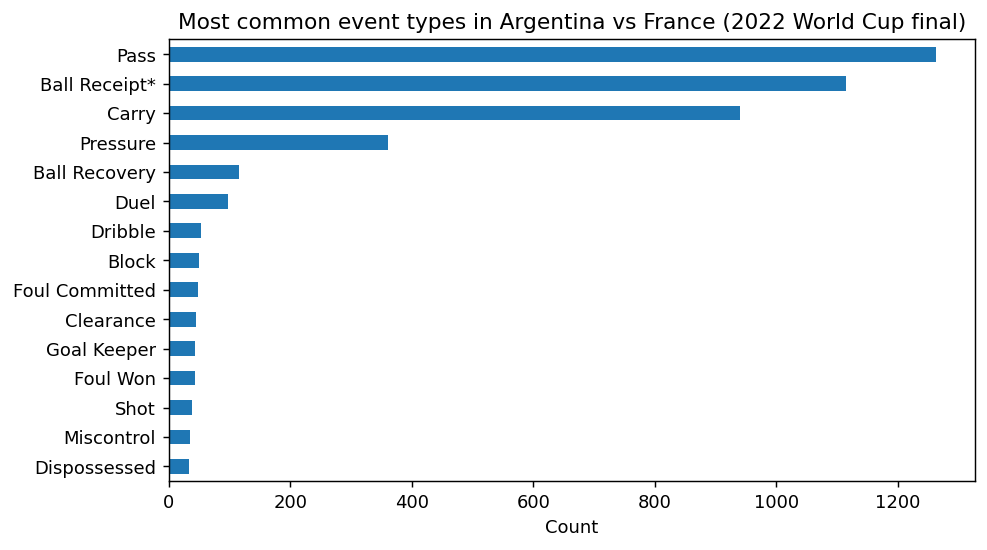

In [180]:
event_counts = events_df["type.name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=130)
event_counts.sort_values().plot(kind="barh", ax=ax)

ax.set_title("Most common event types in Argentina vs France (2022 World Cup final)")
ax.set_xlabel("Count")
ax.set_ylabel("")
plt.show()


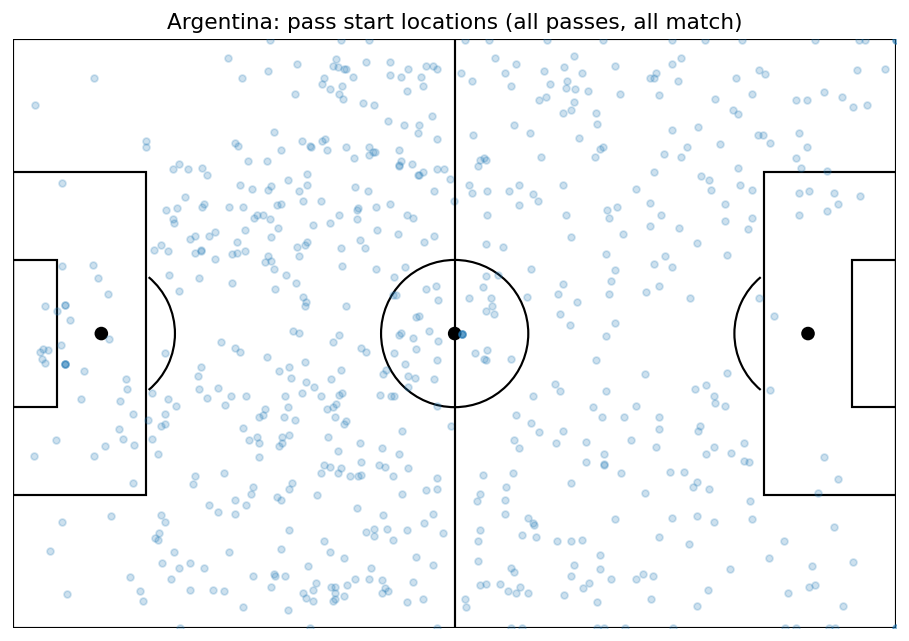

In [181]:
focus_team = "Argentina"

team_passes = events_df[
    (events_df["team.name"] == focus_team) &
    (events_df["type.name"] == "Pass")
].copy()

team_passes[["x", "y"]] = team_passes["location"].apply(lambda loc: pd.Series(extract_xy(loc)))

fig, ax = plt.subplots(figsize=(9, 6), dpi=130)
draw_statsbomb_pitch(ax)
ax.scatter(team_passes["x"], team_passes["y"], s=14, alpha=0.22)

ax.set_title(f"{focus_team}: pass start locations (all passes, all match)")
plt.show()


In [186]:
[i for i in events if 'pass' in i['type']['name'].lower()]

[{'id': 'f651a6c4-55e3-4e0f-a178-59414ba83d6a',
  'index': 5,
  'period': 1,
  'timestamp': '00:00:00.578',
  'minute': 0,
  'second': 0,
  'type': {'id': 30, 'name': 'Pass'},
  'possession': 2,
  'possession_team': {'id': 771, 'name': 'France'},
  'play_pattern': {'id': 9, 'name': 'From Kick Off'},
  'team': {'id': 771, 'name': 'France'},
  'player': {'id': 5487, 'name': 'Antoine Griezmann'},
  'position': {'id': 19, 'name': 'Center Attacking Midfield'},
  'location': [61.0, 40.1],
  'duration': 0.975702,
  'related_events': ['97b5dc82-547a-4f93-a632-a2a8daf5ac98'],
  'pass': {'recipient': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
   'length': 13.364505,
   'angle': 2.907503,
   'height': {'id': 1, 'name': 'Ground Pass'},
   'end_location': [48.0, 43.2],
   'type': {'id': 65, 'name': 'Kick Off'},
   'body_part': {'id': 38, 'name': 'Left Foot'}}},
 {'id': 'a5956ecc-d637-44d2-8705-e2079e12013e',
  'index': 8,
  'period': 1,
  'timestamp': '00:00:02.724',
  'minute': 0,
  'seco

In [187]:
events[5]

{'id': '97b5dc82-547a-4f93-a632-a2a8daf5ac98',
 'index': 6,
 'period': 1,
 'timestamp': '00:00:01.554',
 'minute': 0,
 'second': 1,
 'type': {'id': 42, 'name': 'Ball Receipt*'},
 'possession': 2,
 'possession_team': {'id': 771, 'name': 'France'},
 'play_pattern': {'id': 9, 'name': 'From Kick Off'},
 'team': {'id': 771, 'name': 'France'},
 'player': {'id': 10481, 'name': 'Aurélien Djani Tchouaméni'},
 'position': {'id': 9, 'name': 'Right Defensive Midfield'},
 'location': [48.0, 43.2],
 'related_events': ['f651a6c4-55e3-4e0f-a178-59414ba83d6a']}

### Modeling choices for a passing network

A passing network is always a **modeling choice**.  
The event log is not itself a graph, so we have to decide what counts as a node and what counts as an edge.

For today we will keep the first version simple:

- **nodes** = players
- **directed edge** `i → j` = player `i` completed a pass to player `j`
- **edge weight** = number of completed passes from `i` to `j`
- we will restrict to the **first half**
- and we will keep only passes exchanged between the **starting XI**

Why make those choices?

- restricting to one half avoids mixing too many substitutions and tactical changes together
- using the starting XI keeps the network cleaner and easier to read
- counting repeated passes as weights gives us more information than a simple yes/no adjacency matrix

Later you can change any of these choices.

In [188]:
def get_team_entry(lineups, team_name):
    """Return the lineup dictionary for one team."""
    return next(team for team in lineups if team["team_name"] == team_name)

def get_starters(team_entry):
    """Return the player names marked as Starting XI in the lineup record."""
    starters = []
    for player in team_entry["lineup"]:
        positions = player.get("positions", [])
        # StatsBomb stores positional history; the first position tells us whether
        # the player was in the starting lineup.
        if positions and positions[0].get("start_reason") == "Starting XI":
            starters.append(player["player_name"])
    return starters

def get_nickname_map(team_entry):
    """Map full player names to the display names we want to plot."""
    nicknames = {}
    for player in team_entry["lineup"]:
        full_name = player["player_name"]
        nickname = player.get("player_nickname") or full_name
        nicknames[full_name] = nickname
    return nicknames

for team_entry in lineups:
    starters = get_starters(team_entry)
    nicknames = get_nickname_map(team_entry)
    print(team_entry["team_name"])
    print(", ".join(nicknames[name] for name in starters))
    print()


France
Kylian Mbappé, Adrien Rabiot, Hugo Lloris, Olivier Giroud, Jules Koundé, Ousmane Dembélé, Raphaël Varane, Antoine Griezmann, Theo Hernández, Dayotchanculle Upamecano, Aurélien Tchouaméni

Argentina
Ángel Di María, Nicolás Otamendi, Lionel Messi, Nicolás Tagliafico, Emiliano Martínez, Rodrigo De Paul, Cristian Romero, Alexis MacAllister, Nahuel Molina, Julián Álvarez, Enzo Fernandez



In [189]:
def build_pass_network(
    events,
    lineups,
    team_name,
    period=1,
    starters_only=True,
    allowed_pass_types=("Regular", "Recovery", "Interception"),
):
    """Build a directed weighted pass network for one team.

    A node is a player.
    An edge i -> j means player i completed at least one pass to player j.
    The edge weight is the number of such completed passes.

    We also estimate node positions from average event locations so we can
    place the network back on the pitch.
    """
    team_entry = get_team_entry(lineups, team_name)
    starters = set(get_starters(team_entry)) if starters_only else None
    nicknames = get_nickname_map(team_entry)

    pass_rows = []
    touch_rows = []

    for event in events:
        if event.get("team", {}).get("name") != team_name:
            continue
        if period is not None and event.get("period") != period:
            continue

        player_name = event.get("player", {}).get("name")
        x, y = extract_xy(event.get("location"))

        # Keep non-pass on-ball event locations too, since they help us estimate
        # a reasonable average position for each player.
        if player_name is not None:
            if (not starters_only) or (player_name in starters):
                if not np.isnan(x) and not np.isnan(y):
                    touch_rows.append({
                        "player": player_name,
                        "x": x,
                        "y": y,
                        "type": event.get("type", {}).get("name")
                    })

        if event.get("type", {}).get("name") != "Pass":
            continue

        pass_info = event.get("pass", {})
        pass_outcome = pass_info.get("outcome", {}).get("name")
        pass_type = pass_info.get("type", {}).get("name", "Regular")

        # In StatsBomb, successful passes usually have no explicit outcome field
        if pass_outcome not in [None, "Complete"]:
            continue

        # Keep a simple first version of more standard pass types
        if allowed_pass_types is not None and pass_type not in allowed_pass_types:
            continue

        passer = player_name
        recipient = pass_info.get("recipient", {}).get("name")
        end_x, end_y = extract_xy(pass_info.get("end_location"))

        if passer is None or recipient is None:
            continue

        if starters_only and ((passer not in starters) or (recipient not in starters)):
            continue

        pass_rows.append({
            "passer": passer,
            "recipient": recipient,
            "x": x,
            "y": y,
            "end_x": end_x,
            "end_y": end_y,
            "minute": event.get("minute"),
            "second": event.get("second"),
            "pass_type": pass_type,
        })

    pass_df = pd.DataFrame(pass_rows)
    touch_df = pd.DataFrame(touch_rows)

    G = nx.DiGraph(team=team_name, period=period)

    # Aggregate repeated passes into edge weights
    if not pass_df.empty:
        edge_df = pass_df.groupby(["passer", "recipient"]).size().reset_index(name="weight")
        for _, row in edge_df.iterrows():
            G.add_edge(
                row["passer"],
                row["recipient"],
                weight=int(row["weight"]),
                # Larger pass counts should behave like shorter effective distances
                distance=1.0 / float(row["weight"]),
            )

    # Use average event location as a simple node position on the pitch
    if not touch_df.empty:
        avg_positions = touch_df.groupby("player")[["x", "y"]].mean()
        involvement = pd.concat([pass_df["passer"], pass_df["recipient"]]).value_counts()

        for player in avg_positions.index:
            G.add_node(
                player,
                x=float(avg_positions.loc[player, "x"]),
                y=float(avg_positions.loc[player, "y"]),
                involvement=int(involvement.get(player, 0)),
            )

    return pass_df, touch_df, G, nicknames

def network_summary(G):
    """Return a few whole-network summary statistics."""
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "total_passes": int(sum(d["weight"] for _, _, d in G.edges(data=True))),
        "density": nx.density(G),
        "reciprocity": nx.reciprocity(G),
        "avg_clustering_undirected": nx.average_clustering(G.to_undirected()),
    }

def player_network_table(G):
    """Return one row per player with several centrality/involvement measures."""
    H = G.copy()

    # Betweenness expects a distance, so we use the inverse pass count
    betweenness = nx.betweenness_centrality(H, weight="distance")
    pagerank = nx.pagerank(H, weight="weight")

    rows = []
    for node in H.nodes():
        rows.append({
            "player": node,
            "out_degree": H.out_degree(node),
            "in_degree": H.in_degree(node),
            "out_strength": H.out_degree(node, weight="weight"),
            "in_strength": H.in_degree(node, weight="weight"),
            "total_strength": H.degree(node, weight="weight"),
            "betweenness": betweenness[node],
            "pagerank": pagerank[node],
            "x": H.nodes[node].get("x", np.nan),
            "y": H.nodes[node].get("y", np.nan),
        })

    return pd.DataFrame(rows).sort_values("total_strength", ascending=False)


In [190]:
# Quick first-half summary for both teams
summary_rows = []

for team_name in ["Argentina", "France"]:
    _, _, G_tmp, _ = build_pass_network(events, lineups, team_name=team_name, period=1)
    row = network_summary(G_tmp)
    row["team"] = team_name
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)[
    ["team", "nodes", "edges", "total_passes", "density", "reciprocity", "avg_clustering_undirected"]
]

summary_df


,team,nodes,edges,total_passes,density,reciprocity,avg_clustering_undirected
0,Argentina,11,70,250,0.636364,0.857143,0.836941
1,France,11,57,132,0.518182,0.701754,0.808369


Even before plotting, this table is useful.

For example, density answers a question like:

> *How many of the possible player-to-player passing links actually appeared?*

Reciprocity asks a different question:

> *If player A passed to player B, how often did we also see B pass back to A somewhere in the same half?*

And clustering gives us a rough sense of how "triangular" the passing structure is once we ignore direction.

In [191]:
focus_team = "Argentina"
focus_period = 1

# Build the actual network we are going to inspect in detail
pass_df, touch_df, G_pass, nickname_map = build_pass_network(
    events,
    lineups,
    team_name=focus_team,
    period=focus_period,
)

print(f"Network for {focus_team}, period {focus_period}")
print(network_summary(G_pass))

pass_df.head()


Network for Argentina, period 1
{'nodes': 11, 'edges': 70, 'total_passes': 250, 'density': 0.6363636363636364, 'reciprocity': 0.8571428571428571, 'avg_clustering_undirected': 0.8369408369408369}


,passer,recipient,x,y,end_x,end_y,minute,second,pass_type
0,Cristian Gabriel Romero,Nicolás Hernán Otamendi,24.7,59.4,21.5,32.2,0,34,Regular
1,Nicolás Hernán Otamendi,Cristian Gabriel Romero,24.0,27.1,21.7,49.3,0,39,Regular
2,Cristian Gabriel Romero,Nicolás Hernán Otamendi,22.1,49.8,24.0,27.3,0,43,Regular
3,Nicolás Hernán Otamendi,Nicolás Alejandro Tagliafico,21.7,24.5,26.6,3.1,0,45,Regular
4,Nicolás Alejandro Tagliafico,Alexis Mac Allister,29.2,2.5,45.6,4.2,0,47,Regular


In [192]:
# One row per player, sorted by total weighted involvement
player_stats = player_network_table(G_pass)

player_stats.head(11)


,player,out_degree,in_degree,out_strength,in_strength,total_strength,betweenness,pagerank,x,y
5,Nicolás Hernán Otamendi,6,9,39,34,73,0.316667,0.128125,37.918261,22.616522
1,Enzo Fernandez,9,9,36,35,71,0.188889,0.129026,57.608088,33.976471
7,Cristian Gabriel Romero,8,6,36,28,64,0.100000,0.102347,33.255556,49.655556
10,Rodrigo Javier De Paul,6,7,27,28,55,0.172222,0.107071,58.764957,59.033333
3,Lionel Andrés Messi Cuccittini,8,7,20,25,45,0.069444,0.100608,74.406863,51.778431
0,Alexis Mac Allister,6,7,22,22,44,0.097222,0.099776,68.085106,20.518085
6,Ángel Fabián Di María Hernández,7,7,16,26,42,0.000000,0.105710,83.374286,11.107619
4,Nicolás Alejandro Tagliafico,4,4,18,19,37,0.066667,0.082190,57.631646,7.556962
9,Nahuel Molina Lucero,8,5,18,16,34,0.000000,0.063874,50.401471,70.360294
2,Julián Álvarez,5,6,11,9,20,0.000000,0.046201,75.524138,43.786207


A few comments on the columns above:

- **out-strength** = total number of completed passes made by a player
- **in-strength** = total number of completed passes received by a player
- **total-strength** = total weighted involvement in the pass network
- **betweenness** = how often a player sits on weighted shortest paths
- **pagerank** = a directed-centrality measure that rewards receiving links from well-connected teammates

Do not over-read any one centrality measure.  
Different measures answer different tactical questions.

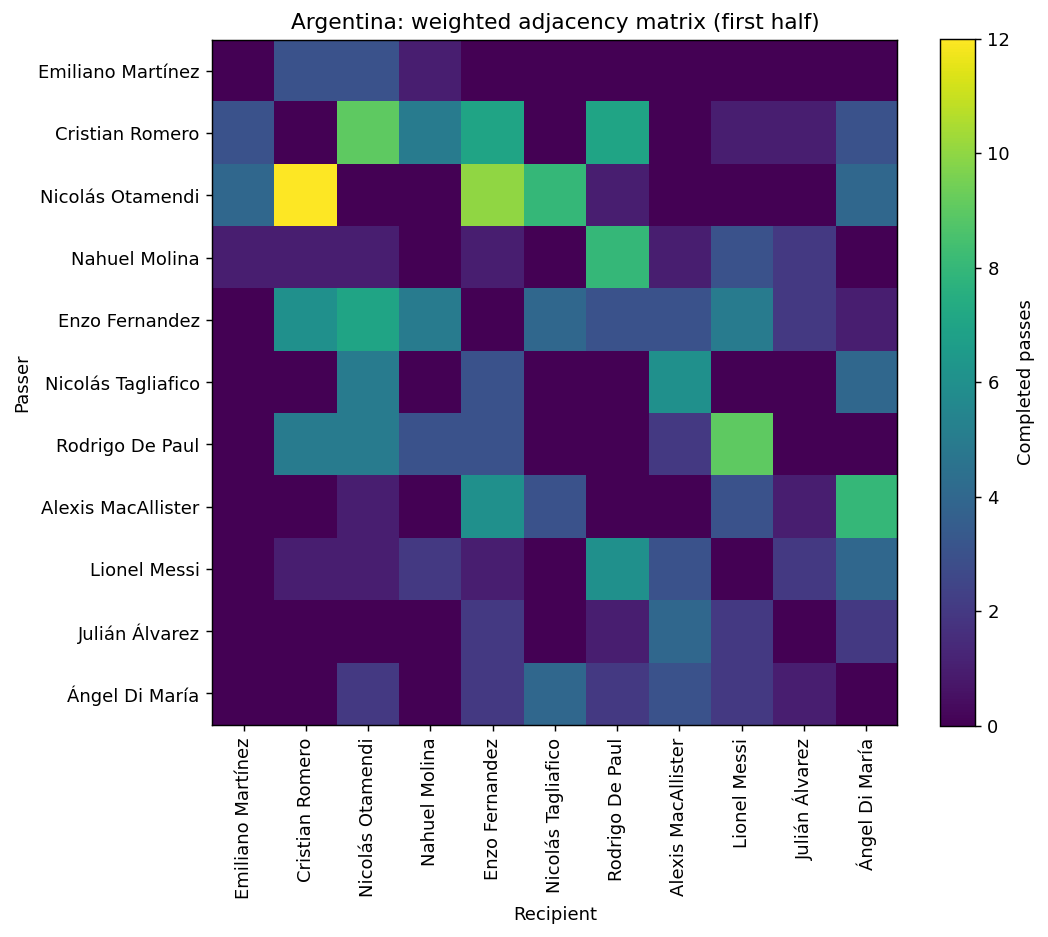

,Damián Emiliano Martínez,Cristian Gabriel Romero,Nicolás Hernán Otamendi,Nahuel Molina Lucero,Enzo Fernandez,Nicolás Alejandro Tagliafico,Rodrigo Javier De Paul,Alexis Mac Allister,Lionel Andrés Messi Cuccittini,Julián Álvarez,Ángel Fabián Di María Hernández
Damián Emiliano Martínez,0,3,3,1,0,0,0,0,0,0,0
Cristian Gabriel Romero,3,0,9,5,7,0,7,0,1,1,3
Nicolás Hernán Otamendi,4,12,0,0,10,8,1,0,0,0,4
Nahuel Molina Lucero,1,1,1,0,1,0,8,1,3,2,0
Enzo Fernandez,0,6,7,5,0,4,3,3,5,2,1
Nicolás Alejandro Tagliafico,0,0,5,0,3,0,0,6,0,0,4
Rodrigo Javier De Paul,0,5,5,3,3,0,0,2,9,0,0
Alexis Mac Allister,0,0,1,0,6,3,0,0,3,1,8
Lionel Andrés Messi Cuccittini,0,1,1,2,1,0,6,3,0,2,4
Julián Álvarez,0,0,0,0,2,0,1,4,2,0,2


In [193]:
# Order players roughly from deeper to more advanced average x-position
# so the adjacency matrix is easier to read
order = player_stats.sort_values(["x", "y"])["player"].tolist()
A = nx.to_pandas_adjacency(G_pass, nodelist=order, weight="weight", dtype=int)

labels = [nickname_map.get(player, player) for player in order]

fig, ax = plt.subplots(figsize=(8.5, 7), dpi=130)
im = ax.imshow(A.values)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90)
ax.set_yticklabels(labels)

ax.set_title(f"{focus_team}: weighted adjacency matrix (first half)")
ax.set_xlabel("Recipient")
ax.set_ylabel("Passer")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Completed passes")

plt.show()

A


In [194]:
def scale_values(values, min_size=250, max_size=1400):
    """Linearly scale an array of values into a plotting range."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return values
    if np.allclose(values.max(), values.min()):
        return np.full(len(values), 0.5 * (min_size + max_size))
    return min_size + (values - values.min()) * (max_size - min_size) / (values.max() - values.min())

def plot_pass_network(G, nickname_map, ax=None, min_edge_weight=3):
    """Plot a directed weighted passing network on a StatsBomb pitch."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 7), dpi=130)

    draw_statsbomb_pitch(ax)

    if G.number_of_edges() > 0:
        max_edge_weight = max(d["weight"] for _, _, d in G.edges(data=True))
    else:
        max_edge_weight = 1

    # Draw lighter edges first, heavier edges later
    for source, target, data in sorted(G.edges(data=True), key=lambda item: item[2]["weight"]):
        weight = data["weight"]
        if weight < min_edge_weight:
            continue

        x1, y1 = G.nodes[source]["x"], G.nodes[source]["y"]
        x2, y2 = G.nodes[target]["x"], G.nodes[target]["y"]

        # Thicker line = more completed passes between the pair
        line_width = 0.5 + 5.0 * (weight / max_edge_weight)
        ax.plot([x1, x2], [y1, y2], linewidth=line_width, alpha=0.35)

    # Scale node size by weighted degree / total passing involvement
    node_strengths = np.array([G.degree(node, weight="weight") for node in G.nodes()], dtype=float)
    node_sizes = scale_values(node_strengths)

    xs = [G.nodes[node]["x"] for node in G.nodes()]
    ys = [G.nodes[node]["y"] for node in G.nodes()]

    ax.scatter(xs, ys, s=node_sizes, alpha=0.9, edgecolors="black", linewidths=0.7)

    for node in G.nodes():
        label = nickname_map.get(node, node)
        ax.text(
            G.nodes[node]["x"],
            G.nodes[node]["y"],
            label,
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=0.3),
        )

    ax.set_title(
        f"{G.graph.get('team', 'Team')} passing network, first half\n"
        f"(completed passes between starters; line width = pass count)"
    )
    return ax


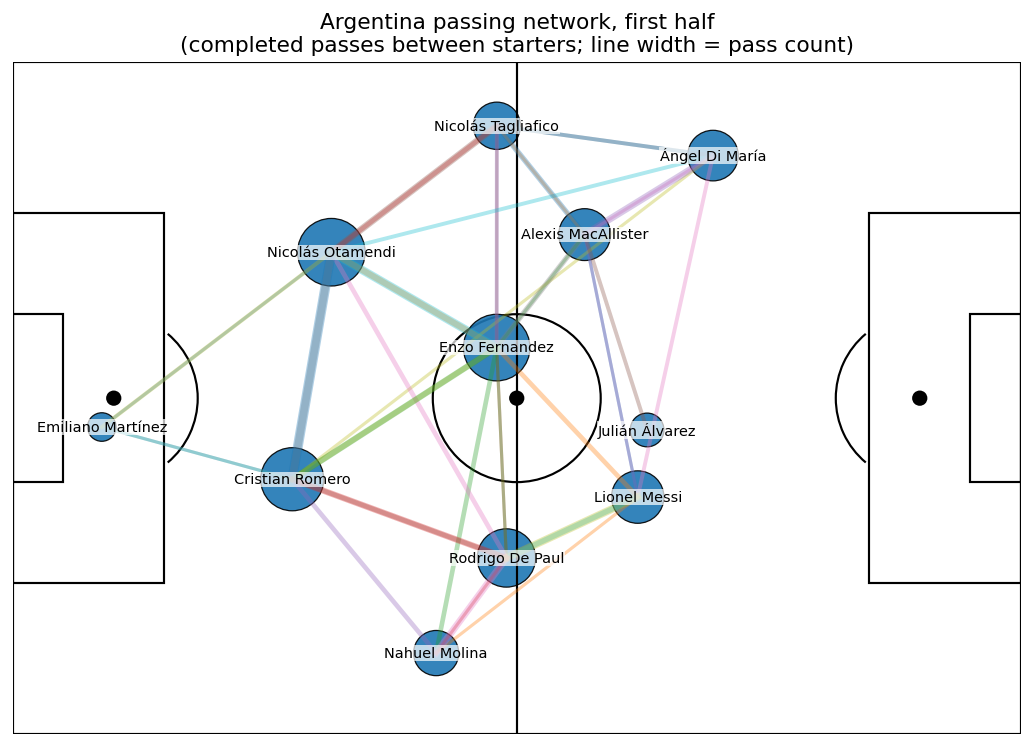

In [195]:
fig, ax = plt.subplots(figsize=(10, 7), dpi=130)
plot_pass_network(G_pass, nickname_map, ax=ax, min_edge_weight=3)
plt.show()


### What did we just do?

We started with a raw event log and turned it into several familiar network objects:

- an **edgelist** of passes
- a **directed weighted graph**
- a **weighted adjacency matrix**
- a spatial **node-link diagram** on the pitch

So this is the same workflow from the first half of class.  
The only difference is that the edges now came from a real dataset instead of a toy example.

## Your turn

Try one or more of the following extensions:

1. Change `focus_team` to `"France"` and compare the network statistics.
2. Change `focus_period` from `1` to `2` and see how the structure changes after halftime.
3. Remove the `starters_only=True` restriction and see how substitutions change the graph.
4. Include or exclude different `allowed_pass_types` and note what happens to density and reciprocity.
5. Build a **full-match** network instead of a first-half network.
6. Compute a different centrality measure in `networkx` and decide what tactical question it answers.
7. Instead of player-to-player passes, divide the pitch into zones and build a **zone passing network**.

There is no single correct passing network.  
The graph you get depends on the modeling choices you make, so those choices should be stated clearly.

__________

## References and further resources

1. `networkx` documentation and tutorials: https://networkx.org/documentation/stable/tutorial.html
2. StatsBomb open-data repository: https://github.com/statsbomb/open-data
3. StatsBomb open-data specification (`doc/` folder in the repo): https://github.com/statsbomb/open-data/tree/master/doc
4. López Peña, J., & Touchette, H. (2012). *A network theory analysis of football strategies*. arXiv:1206.6904
5. Buldú, J. M., Busquets, J., Martínez, J. H., Herrera-Diestra, J. L., Echegoyen, I., Galeano, J., & Luque, J. (2018). *Using Network Science to Analyse Football Passing Networks: Dynamics, Space, Time, and the Multilayer Nature of the Game*. Frontiers in Psychology, 9, 1900.
6. Caicedo-Parada, S., et al. (2020). *Passing Networks and Tactical Action in Football*. International Journal of Environmental Research and Public Health, 17(21), 7856.
7. Alves, R., Dias, G., Nunes, N. A., Querido, S. M., & Vaz, V. (2025). *Social network analysis in football: a systematic review of performance and tactical applications*. Frontiers in Psychology.